In [1]:
# LVDT_simulation/tests/demo.ipynb
import sys
sys.path.append('..')
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from simulation import data_handler
from simulation.simulator import SimulatorManager

### Demo

In [ ]:
sim_manager = SimulatorManager(input_jsonname='demo_lvdt.json', output_filename='demo_result.h5', 
                                output_dir="../data/demo", auto_close=False) 
sim_manager.run_simulation()

{'intercept': -0.0007382355396108926,
 'p_value': 5.046655657689232e-12,
 'r_value': 0.9979140294462283,
 'slope': 0.007357376521825896,
 'std_err': 0.00015865402120168233}


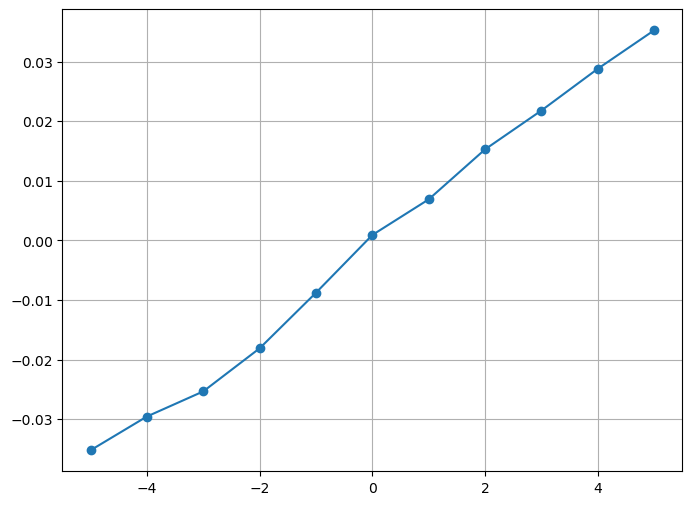

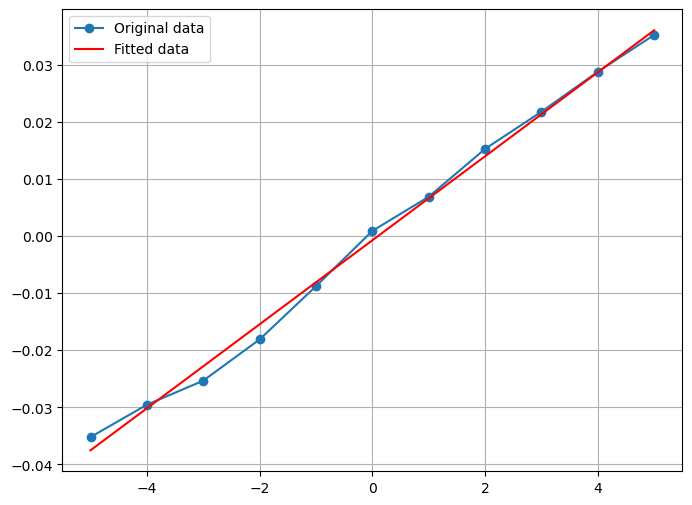

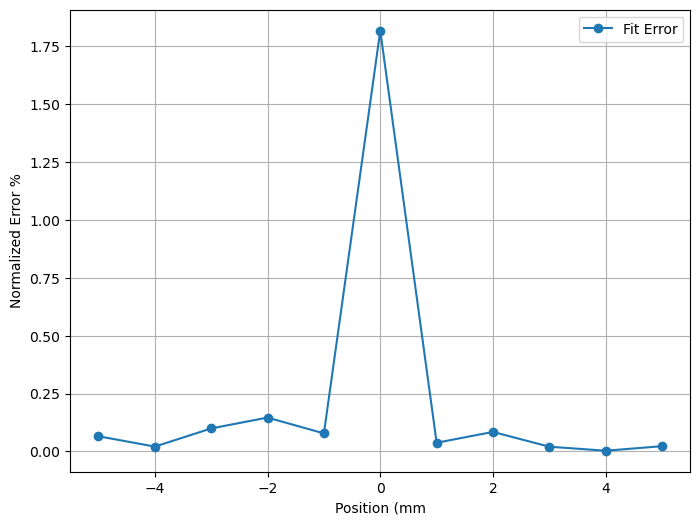

In [2]:
filename = "../data/demo/demo_result.h5"

data_dict = data_handler.load_data(filename)
config_data = data_handler.get_config_data(data_dict)
volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=True)
curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

position = volt_data['position']
pickup_voltage = volt_data['Middle_Coil']['voltage_abs']
excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

norm_voltage_volt = pickup_voltage / excitation_voltage
norm_voltage_curr = pickup_voltage / excitation_current

fit_params = data_handler.linear_fit(position, norm_voltage_curr, unit="V")
pprint(fit_params)

data_handler.plot_lvdt_data(xdata=position, ydata=norm_voltage_curr, unit="V")
data_handler.plot_linear_fit(position, norm_voltage_curr, unit="V")
data_handler.plot_linear_fit_error(position, norm_voltage_curr, unit="V", norm=True)

### Analysis 

{'intercept': 0.0008098251657756878,
 'p_value': 9.230473381589421e-13,
 'r_value': 0.9985702292999686,
 'slope': 0.007278936708589263,
 'std_err': 0.00012988559185523585}


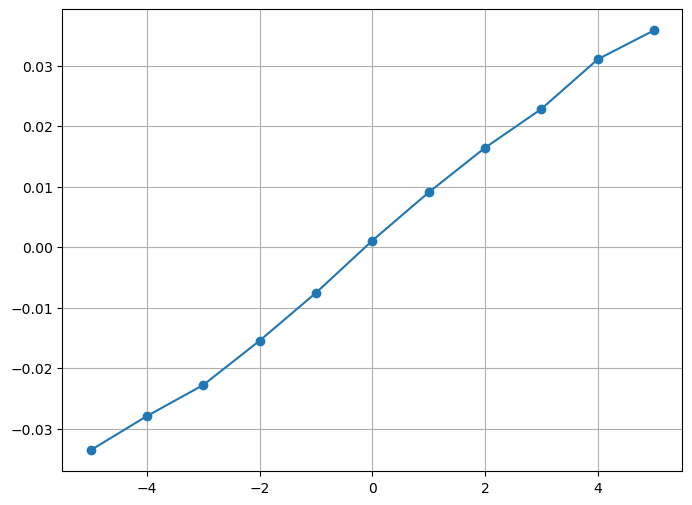

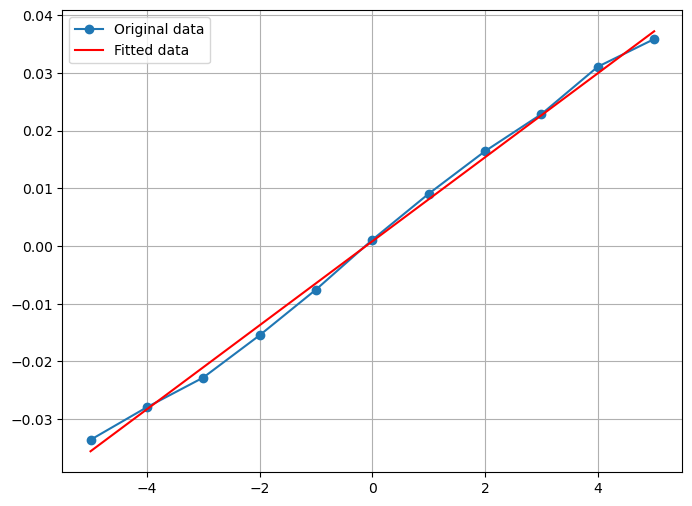

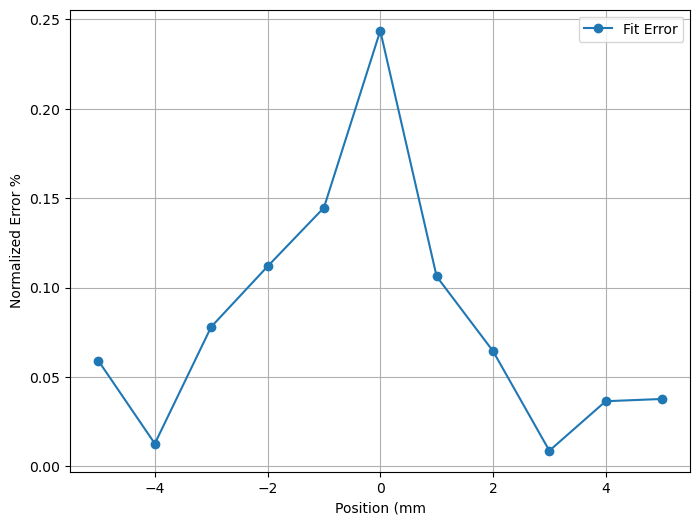

{'intercept': 0.0004942884072064557,
 'p_value': 3.580171987969169e-126,
 'r_value': 0.9984611809031806,
 'slope': 0.007418271052803138,
 'std_err': 4.140907772179047e-05}


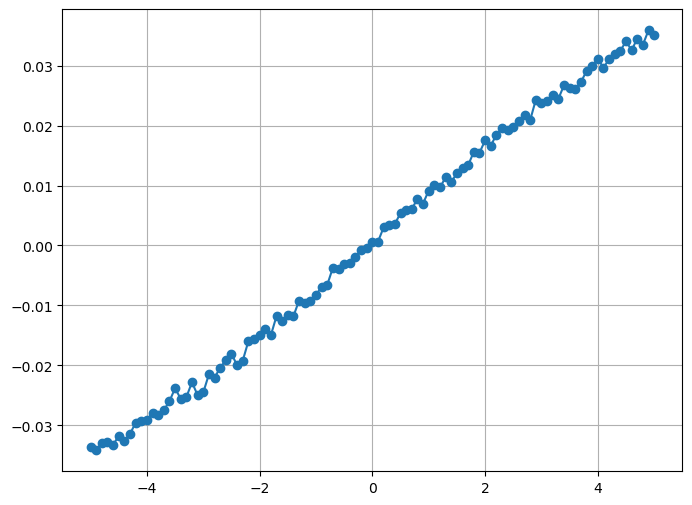

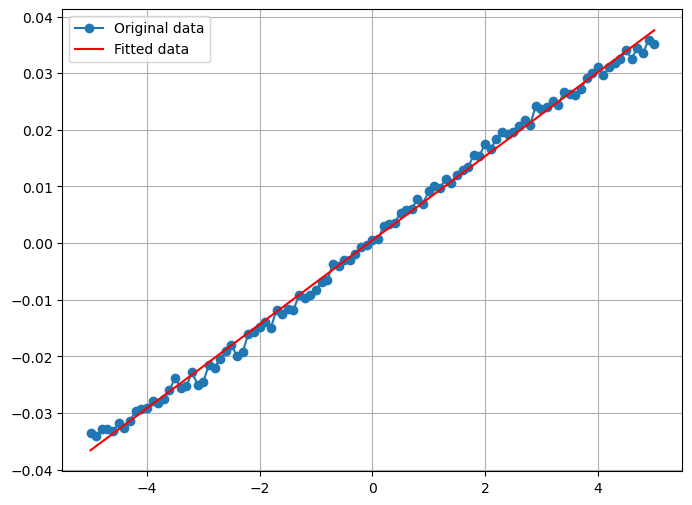

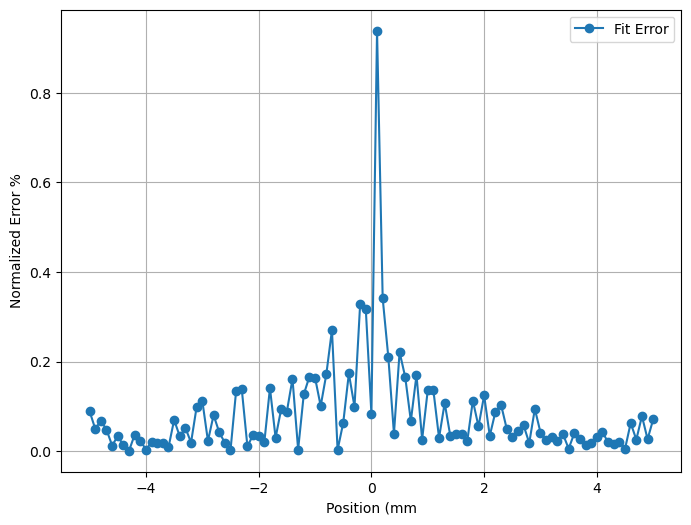

In [3]:
sim_files = ["../data/prototype/lvdt_alucoil_10mm_1mm.h5",
            "../data/prototype/lvdt_alucoil_10mm_0p1mm.h5"]

for file in sim_files:
    data_dict = data_handler.load_data(file)
    config_data = data_handler.get_config_data(data_dict)
    volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=True)
    curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

    position = volt_data['position']
    pickup_voltage = volt_data['Middle_Coil']['voltage_abs']
    excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
    excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

    norm_voltage_volt = pickup_voltage / excitation_voltage
    norm_voltage_curr = pickup_voltage / excitation_current

    fit_params = data_handler.linear_fit(position, norm_voltage_curr, unit="V")
    pprint(fit_params)

    data_handler.plot_lvdt_data(xdata=position, ydata=norm_voltage_curr, unit="V")
    data_handler.plot_linear_fit(position, norm_voltage_curr, unit="V")
    data_handler.plot_linear_fit_error(position, norm_voltage_curr, unit="V", norm=True)

### Simulation vs Measurement

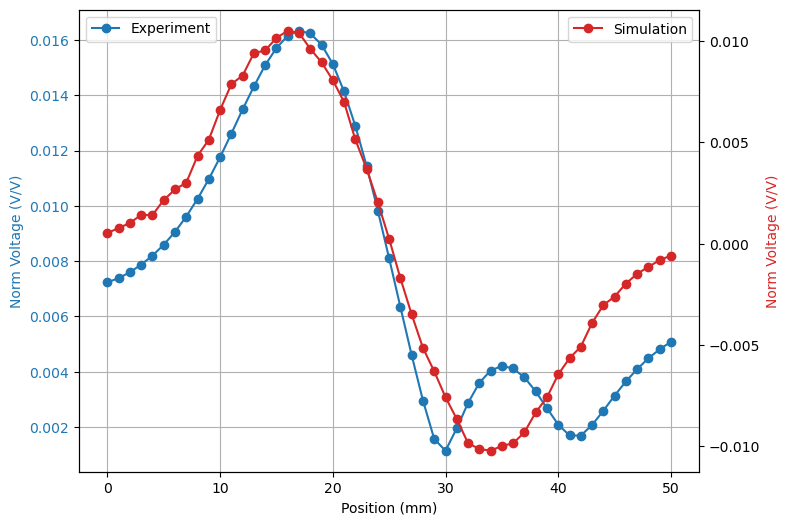

In [4]:
# measurement datas
exp_file = '../data/prototype/lvdt_alucoil_50mm_1mm_measurement.h5'
f = h5py.File(exp_file, 'r')
exp_pos = np.array(f['PI'][:])
exp_pickup_amp = np.array(f['Fit_Amp'][:])
exp_input_waveform = np.array(f['excitation'][:])
exp_pickup_waveform = np.array(f['pick-up'][:])

exp_input_volt = np.mean([np.std(x)*np.sqrt(2) for x in exp_input_waveform]) # it is already the readout from two excitation coils
exp_pickup_volt = np.array([np.std(x)*np.sqrt(2) for x in exp_pickup_waveform])
exp_pickup_volt_norm = (exp_pickup_volt / exp_input_volt)

# simulation data
sim_file = "../data/prototype/lvdt_alucoil_50mm_1mm_simulation.h5"
data_dict = data_handler.load_data(sim_file)
lvdt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage' ,flip_sign=True)
sim_pos = lvdt_data['position']+25
sim_input_volt = np.mean(abs(lvdt_data['Lower_Coil']['voltage_abs']))*2 # sum of two excitation coils
sim_pickup_volt = np.array(lvdt_data['Middle_Coil']['voltage_abs'])[::-1]
sim_pickup_volt_norm = (sim_pickup_volt / sim_input_volt) 

figure, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(exp_pos, exp_pickup_volt_norm, marker = 'o', label='Experiment', color='tab:blue')
ax1.set_xlabel('Position (mm)')
ax1.set_ylabel('Norm Voltage (V/V)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(sim_pos, sim_pickup_volt_norm, marker = 'o', label='Simulation', color='tab:red')
ax2.set_ylabel('Norm Voltage (V/V)', color='tab:red')
ax2.legend(loc='upper right')
ax1.grid()